
── g = 5 labelled examples ──────────────────────
  Naive                 Acc=0.6733  BalAcc=0.6733  F1=0.7538  AUC=0.1388
  Self-Training         Acc=0.5000  BalAcc=0.5000  F1=0.6667  AUC=0.6357
  Label Propagation     Acc=0.7267  BalAcc=0.7267  F1=0.7831  AUC=0.9438
  Label Spreading       Acc=0.7933  BalAcc=0.7933  F1=0.8249  AUC=0.9083

── g = 10 labelled examples ──────────────────────
  Naive                 Acc=0.7467  BalAcc=0.7467  F1=0.7957  AUC=0.0286
  Self-Training         Acc=0.7467  BalAcc=0.7467  F1=0.7957  AUC=0.0286
  Label Propagation     Acc=0.9000  BalAcc=0.9000  F1=0.9068  AUC=0.9835
  Label Spreading       Acc=0.9600  BalAcc=0.9600  F1=0.9600  AUC=0.9959

── g = 20 labelled examples ──────────────────────
  Naive                 Acc=0.8200  BalAcc=0.8200  F1=0.8457  AUC=0.9767
  Self-Training         Acc=0.8400  BalAcc=0.8400  F1=0.8605  AUC=0.8517
  Label Propagation     Acc=0.8067  BalAcc=0.8067  F1=0.8362  AUC=0.9820
  Label Spreading       Acc=0.8400  BalAcc

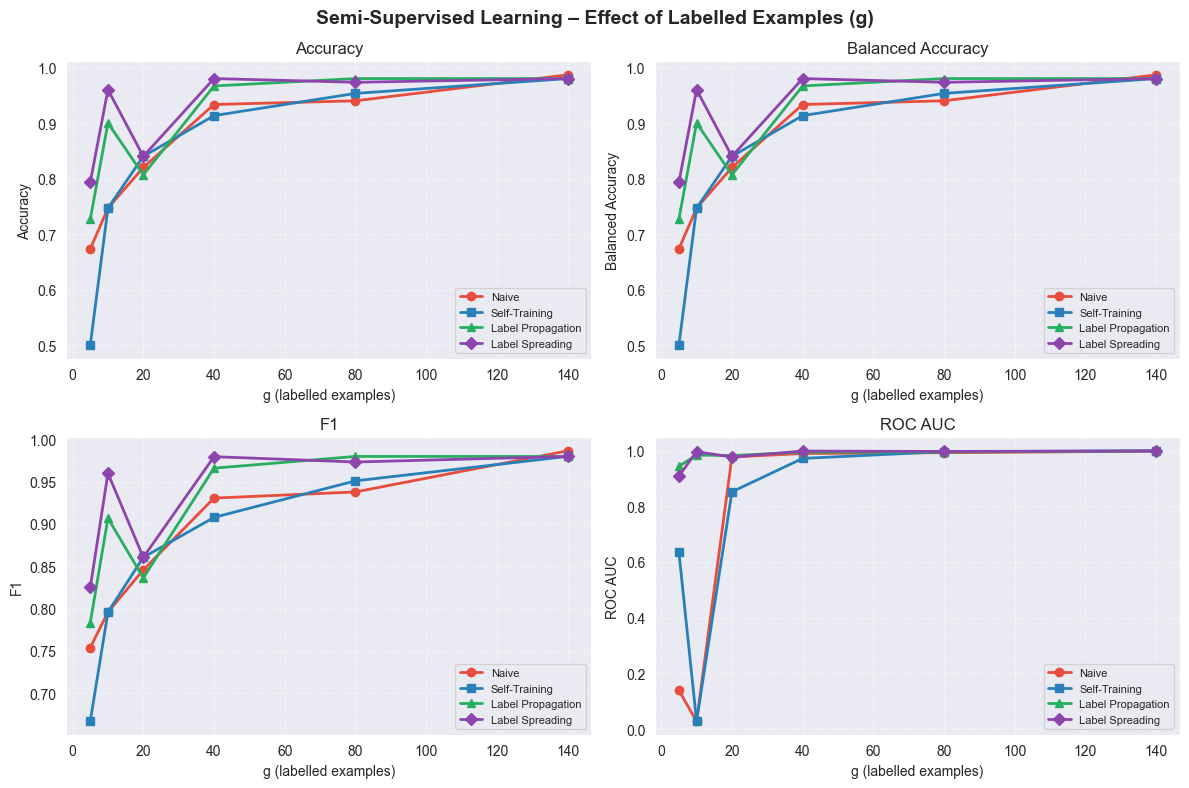

In [2]:
"""
Lab 13: Semi-Supervised Learning
Compares: Naive (labeled only), Self-Training, Label Propagation, Label Spreading
Dataset: make_moons (binary classification)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.semi_supervised import SelfTrainingClassifier, LabelPropagation, LabelSpreading
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score

# ── 1. Generate dataset ────────────────────────────────────────────────────────
RANDOM_STATE = 42
X, y = make_moons(n_samples=500, noise=0.2, random_state=RANDOM_STATE)

# ── 2. Train / test split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

# ── 3. Helper: create partially-labelled training set ─────────────────────────
def make_partially_labelled(y_train, g, random_state=42):
    """Return labels where only g examples keep their label; rest become -1."""
    rng = np.random.default_rng(random_state)
    y_partial = np.full_like(y_train, fill_value=-1)
    labelled_idx = rng.choice(len(y_train), size=g, replace=False)
    y_partial[labelled_idx] = y_train[labelled_idx]
    return y_partial, labelled_idx

# ── 4. Evaluate one configuration ─────────────────────────────────────────────
def evaluate(name, clf, X_tr, y_tr, X_te, y_te):
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    # For ROC AUC use probability / decision function when available
    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_te)[:, 1]
    elif hasattr(clf, "decision_function"):
        y_score = clf.decision_function(X_te)
    else:
        y_score = y_pred.astype(float)
    return {
        "Method": name,
        "Accuracy":          round(accuracy_score(y_te, y_pred), 4),
        "Balanced Accuracy": round(balanced_accuracy_score(y_te, y_pred), 4),
        "F1":                round(f1_score(y_te, y_pred), 4),
        "ROC AUC":           round(roc_auc_score(y_te, y_score), 4),
    }

# ── 5. Compare methods across different values of g ───────────────────────────
g_values = [5, 10, 20, 40, 80, 140]   # number of labelled examples
method_names = ["Naive", "Self-Training", "Label Propagation", "Label Spreading"]

# Store results: results[method_name] = list of metric dicts (one per g)
results = {m: [] for m in method_names}

for g in g_values:
    y_partial, labelled_idx = make_partially_labelled(y_train, g)

    # ── (a) Naive: train SVC on labelled examples only ───────────────────────
    X_labelled = X_train[labelled_idx]
    y_labelled  = y_train[labelled_idx]
    naive_clf = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
    r = evaluate("Naive", naive_clf, X_labelled, y_labelled, X_test, y_test)

    # ── (b) Self-Training ─────────────────────────────────────────────────────
    base_svc = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
    st_clf = SelfTrainingClassifier(base_svc, threshold=0.75, max_iter=100)
    r_st = evaluate("Self-Training", st_clf, X_train, y_partial, X_test, y_test)

    # ── (c) Label Propagation ─────────────────────────────────────────────────
    lp_clf = LabelPropagation(kernel="rbf", max_iter=1000)
    r_lp = evaluate("Label Propagation", lp_clf, X_train, y_partial, X_test, y_test)

    # ── (d) Label Spreading ───────────────────────────────────────────────────
    ls_clf = LabelSpreading(kernel="rbf", max_iter=1000)
    r_ls = evaluate("Label Spreading", ls_clf, X_train, y_partial, X_test, y_test)

    for name, res in zip(method_names, [r, r_st, r_lp, r_ls]):
        results[name].append(res)
    print(f"\n── g = {g} labelled examples ──────────────────────")
    for res in [r, r_st, r_lp, r_ls]:
        print(f"  {res['Method']:<20}  Acc={res['Accuracy']:.4f}  "
              f"BalAcc={res['Balanced Accuracy']:.4f}  "
              f"F1={res['F1']:.4f}  AUC={res['ROC AUC']:.4f}")

# ── 6. Plot: how g affects each metric ────────────────────────────────────────
metrics   = ["Accuracy", "Balanced Accuracy", "F1", "ROC AUC"]
colors    = {"Naive": "#e74c3c", "Self-Training": "#2980b9",
             "Label Propagation": "#27ae60", "Label Spreading": "#8e44ad"}
markers   = {"Naive": "o", "Self-Training": "s",
             "Label Propagation": "^", "Label Spreading": "D"}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Semi-Supervised Learning – Effect of Labelled Examples (g)",
             fontsize=14, fontweight="bold")

for ax, metric in zip(axes.flat, metrics):
    for method in method_names:
        vals = [r[metric] for r in results[method]]
        ax.plot(g_values, vals,
                label=method,
                color=colors[method],
                marker=markers[method],
                linewidth=2,
                markersize=6)
    ax.set_title(metric)
    ax.set_xlabel("g (labelled examples)")
    ax.set_ylabel(metric)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
